# Evaluación Parcial 1 – Fundamentos de Deep Learning
## Clasificación de imágenes Fashion‑MNIST con MLP

**Objetivo:** Implementar una red neuronal multicapa (MLP) para clasificar imágenes de moda en 10 categorías.

**Dataset:** Fashion‑MNIST.

**Integrantes:**
- Matías Gutiérrez
- David Larenas
- Francisco Silva

---

## Mapeo Notebook → Indicadores de la Rúbrica

| Sección del Notebook | Indicador(es) Encargo (IEE) | Indicador(es) Presentación (IP) |
|----------------------|-----------------------------|----------------------------------|
| 1. Carga y preprocesamiento | IEE 1.1.1 | IP 1.1.1 |
| 2. Definición modelo base | IEE 1.1.2 (configuración inicial), IEE 1.2.1 (funciones base), IEE 1.3.1 (uso TF/Keras) | IP 1.2.1, IP 1.3.1 |
| 2.1 Entrenamiento inicial | IEE 1.1.2, IEE 1.1.3 (primer experimento implícito) | IP 1.1.2 |
| 2.2 Experimento 1 – Learning rate | IEE 1.1.3, IEE 1.1.4 (ajuste) | IP 1.1.2, IP 1.1.3 |
| 2.3 Experimento 2 – Batch size | IEE 1.1.3, IEE 1.1.4 | IP 1.1.2, IP 1.1.3 |
| 2.4 Experimento 3 – Arquitectura | IEE 1.1.3, IEE 1.1.4 | IP 1.1.2, IP 1.1.3 |
| 3. Comparación funciones de activación/error | IEE 1.2.1, IEE 1.2.2, IEE 1.2.3 | IP 1.2.1, IP 1.2.2, IP 1.2.3 |
| 4. Optimización y Regularización | IEE 1.3.2, IEE 1.3.3 | IP 1.3.2, IP 1.3.3 |
| 5. Evaluación del modelo final | IEE 1.4.1, IEE 1.4.2 | IP 1.4.1, IP 1.4.2 |
| 6. Comparación de configuraciones | IEE 1.4.3 | IP 1.4.3 |
| 7. Conclusiones | (soporte para todos los IEE) | (soporte para todos los IP) |

*Los indicadores IP se refieren a la defensa oral, así que las gráficas y explicaciones que dejéis en el notebook os servirán de apoyo directo.*

---

## Importaciones

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.callbacks import EarlyStopping, ModelCheckpoint

## 1. Carga y Preprocesamiento de Datos

Obtendremos el conjunto Fashion‑MNIST, exploraremos su estructura y la transformaremos para entrenar un Perceptrón Multicapa (MLP).

### Carga del Dataset (Fashion‑MNIST)

Utilizamos la función `keras.datasets.fashion_mnist.load_data()`, que retorna dos tuplas:  
- `(train_imgs, train_labs)`: 60 000 imágenes de entrenamiento y sus etiquetas.  
- `(test_imgs, test_labs)`: 10 000 imágenes de prueba y sus etiquetas.  

Cada imagen es una matriz de 28×28 píxeles en escala de grises (intensidad entre 0 y 255). Las etiquetas son enteros de 0 a 9, cada uno representando una categoría de moda.

In [3]:
# Cargar datos
(train_imgs, train_labs), (test_imgs, test_labs) = keras.datasets.fashion_mnist.load_data()

print("Forma de train_imgs:", train_imgs.shape)
print("Forma de train_labs:", train_labs.shape)
print("Forma de test_imgs :", test_imgs.shape)
print("Forma de test_labs :", test_labs.shape)
print("Tipo de datos de imagen:", train_imgs.dtype)
print("Rango de valores de píxel: de", train_imgs.min(), "a", train_imgs.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma de train_imgs: (60000, 28, 28)
Forma de train_labs: (60000,)
Forma de test_imgs : (10000, 28, 28)
Forma de test_labs : (10000,)
Tipo de datos de imagen: uint8
Rango de valores de píxel: de 0 a 255


**Justificación:** Verificar las dimensiones y el rango de datos es el primer paso para asegurar que la carga ha sido correcta y para planificar el preprocesamiento. Como las imágenes están en una escala de 0 a 255, será necesario normalizarlas.

### Mapeo de etiquetas

El dataset asigna un número entero a cada categoría. Definimos una lista con los nombres correspondientes para que las visualizaciones y métricas sean interpretables.

In [4]:
# Estos son los nombres de las 10 clases de Fashion‑MNIST
class_names = ['T‑shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Clases:", class_names)

Clases: ['T‑shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Visualización de muestras

Mostramos una grilla de 5×5 imágenes del conjunto de entrenamiento con sus etiquetas reales. Esto nos permite validar visualmente la relación imagen‑etiqueta y familiarizarnos con los tipos de prendas.

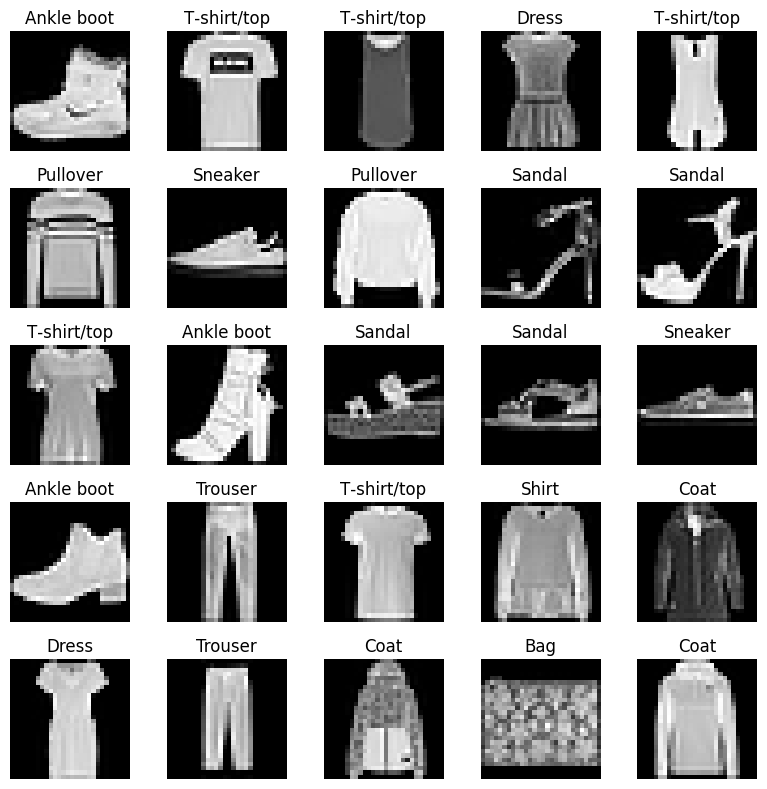

In [5]:
# Grilla 5x5
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
axes = axes.ravel()
for i in range(25):
    axes[i].imshow(train_imgs[i], cmap='gray')
    axes[i].set_title(class_names[train_labs[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

**Justificación:** La inspección visual directa complementa la verificación numérica y permite detectar posibles errores en el etiquetado.

### Balance de clases

Una distribución equilibrada evita que el modelo favorezca a las clases mayoritarias. Comprobamos la frecuencia de cada clase en el conjunto de entrenamiento.

T‑shirt/top : 6000
Trouser     : 6000
Pullover    : 6000
Dress       : 6000
Coat        : 6000
Sandal      : 6000
Shirt       : 6000
Sneaker     : 6000
Bag         : 6000
Ankle boot  : 6000


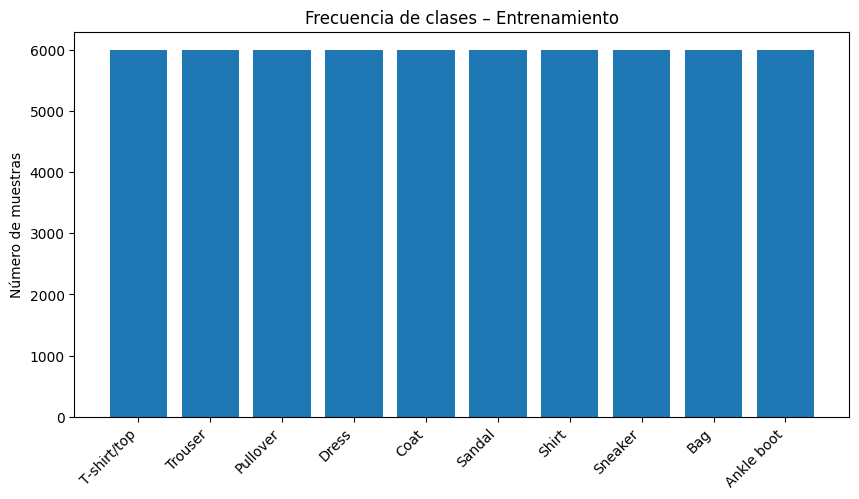

In [6]:
# Conteo de etiquetas
unique, counts = np.unique(train_labs, return_counts=True)
freq = {class_names[u]: c for u, c in zip(unique, counts)}

# Mostrar frecuencias
for name, count in freq.items():
    print(f"{name:12s}: {count}")

# Gráfico de barras
plt.figure(figsize=(10, 5))
plt.bar(range(10), counts, tick_label=class_names)
plt.title('Frecuencia de clases – Entrenamiento')
plt.ylabel('Número de muestras')
plt.xticks(rotation=45, ha='right')
plt.show()

**Justificación:** Confirmamos que las 10 clases están balanceadas (6 000 muestras cada una). Por tanto, la exactitud (accuracy) será una métrica adecuada para evaluar el desempeño global, ya que no hay una clase desproporcionada que pueda sesgarla.

### Preprocesamiento para MLP

El Perceptrón Multicapa (MLP) espera como entrada vectores unidimensionales. Por tanto:
1. **Aplanamos** cada imagen de 28×28 a un vector de 784 píxeles.  
2. **Normalizamos** los valores de intensidad dividiendo por 255, llevándolos al intervalo [0,1].  

Esta normalización es crucial: valores grandes de entrada provocan gradientes de gran magnitud, lo que puede desestabilizar el descenso del gradiente (backpropagation) y ralentizar la convergencia. Con entrada normalizada, el gradiente es más suave y los pesos se actualizan de forma más controlada (ver Experiencia de Aprendizaje 1, unidades 1.3 y 1.4).

In [7]:
# Aplanado y normalización
X_train = train_imgs.reshape(-1, 28*28) / 255.0
X_test  = test_imgs.reshape(-1, 28*28) / 255.0

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Valores X_train en [", X_train.min(), ",", X_train.max(), "]")

X_train shape: (60000, 784)
X_test shape : (10000, 784)
Valores X_train en [ 0.0 , 1.0 ]


### One‑hot encoding de las etiquetas

Para un clasificador con salida softmax y pérdida de entropía cruzada categórica, las etiquetas deben representarse como vectores one‑hot. Así, si la etiqueta real es la clase 3, el vector correspondiente será `[0,0,0,1,0,0,0,0,0,0]`. Esto permite calcular correctamente la divergencia entre la distribución predicha y la real.

In [8]:
Y_train = keras.utils.to_categorical(train_labs, 10)
Y_test  = keras.utils.to_categorical(test_labs, 10)

print("Y_train shape:", Y_train.shape)
print("Y_test shape :", Y_test.shape)
print("Ejemplo: etiqueta original", train_labs[0], "→ one‑hot", Y_train[0])

Y_train shape: (60000, 10)
Y_test shape : (10000, 10)
Ejemplo: etiqueta original 9 → one‑hot [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


**Justificación:** La entropía cruzada categórica comparará directamente la salida softmax (un vector de probabilidades) con este vector one‑hot. Cualquier otra representación no sería compatible con la función de pérdida elegida.

### Resumen

En resumen se podria decir que realizamos lo siguiente:
- Cargamos 60 000 imágenes de entrenamiento y 10 000 de prueba.  
- Verificamos el balance de clases.  
- Aplanamos las imágenes a 784 características y normalizamos a [0,1].  
- Convertimos las etiquetas a formato one‑hot.  

## 2. Definición de Modelo Base

Construiremos un Perceptrón Multicapa con dos capas ocultas (128 y 64 neuronas) y función de activación ReLU. La capa de salida utiliza softmax para clasificar en 10 categorías. Compilamos con entropía cruzada categórica y optimizador SGD con learning rate 0.01, que será nuestro punto de partida.

La arquitectura elegida sigue las siguientes recomendaciones:  
- ReLU en capas ocultas para evitar el desvanecimiento del gradiente.  
- Softmax en la salida para producir una distribución de probabilidad.  
- SGD para implementar el descenso del gradiente estocástico clásico.  
- Entropía cruzada categórica es la función de pérdida adecuada para clasificación multiclase.

In [9]:
# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# Creación del modelo base
model_base = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compilación
model_base.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy']
)

model_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Justificación:**  
- **ReLU:** Induce no linealidad sin saturación, acelerando la convergencia.  
- **Entropía cruzada:** Mide la divergencia entre la distribución predicha (softmax) y la real (one‑hot), ideal para clasificación.  
- **SGD con lr=0.01:** Valor inicial moderado que exploraremos en profundidad en el experimento 2.2.

### 2.1 Entrenamiento inicial (20 épocas, batch_size=32)

Establecemos una línea base con los parámetros `epochs=20`, `batch_size=32`. Guardamos el historial para comparar con los experimentos posteriores.

In [10]:
history = model_base.fit(X_train, Y_train,
                         epochs=20, batch_size=32,
                         validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7486 - loss: 0.7701 - val_accuracy: 0.8187 - val_loss: 0.5386
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8236 - loss: 0.5063 - val_accuracy: 0.8352 - val_loss: 0.4762
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8400 - loss: 0.4586 - val_accuracy: 0.8442 - val_loss: 0.4456
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8492 - loss: 0.4308 - val_accuracy: 0.8505 - val_loss: 0.4263
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8559 - loss: 0.4108 - val_accuracy: 0.8563 - val_loss: 0.4123
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8611 - loss: 0.3949 - val_accuracy: 0.8593 - val_loss: 0.4018
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8664 - loss: 0.3817 - val_accuracy: 0.8624 - val_loss: 0.3919
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8695 - loss: 0.3702 - 

**Curvas de pérdida y accuracy en validación:**

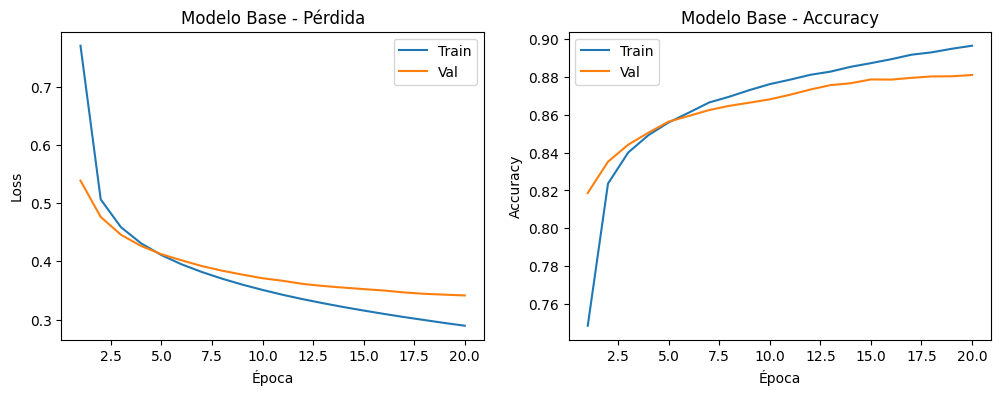

In [11]:
def plot_history(history, title):
    epochs = range(1, len(history['loss'])+1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(epochs, history['loss'], label='Train')
    ax1.plot(epochs, history['val_loss'], label='Val')
    ax1.set_title(f'{title} - Pérdida')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, history['accuracy'], label='Train')
    ax2.plot(epochs, history['val_accuracy'], label='Val')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    plt.show()

plot_history(history.history, 'Modelo Base')

**Observación:** La pérdida en validación disminuye de forma continua y el accuracy aumenta progresivamente. No se evidencian signos de sobreajuste (overfitting), ya que las curvas de entrenamiento y validación se mantienen estables y cercanas entre sí, lo que indica que el modelo está generalizando correctamente en esta fase.

### 2.2 Experimento 1: Variar learning rate

**Parámetros fijos:** batch_size=32, epochs=20, arquitectura [128,64,10].  
**Valores probados:** lr = 0.1, 0.01, 0.001.

In [12]:
def build_and_train(lr, batch_size=32, epochs=20):
    """Construye y entrena un MLP base con SGD y un learning rate dado."""
    tf.random.set_seed(42)
    np.random.seed(42)
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    opt = keras.optimizers.SGD(learning_rate=lr)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    hist = model.fit(X_train, Y_train,
                     epochs=epochs, batch_size=batch_size,
                     validation_split=0.2, verbose=0)
    return hist

# Entrenar con las tres tasas
hist_lr_01   = build_and_train(0.1)
hist_lr_001  = build_and_train(0.01)
hist_lr_0001 = build_and_train(0.001)

**Gráficos comparativos de pérdida y accuracy en validación:**

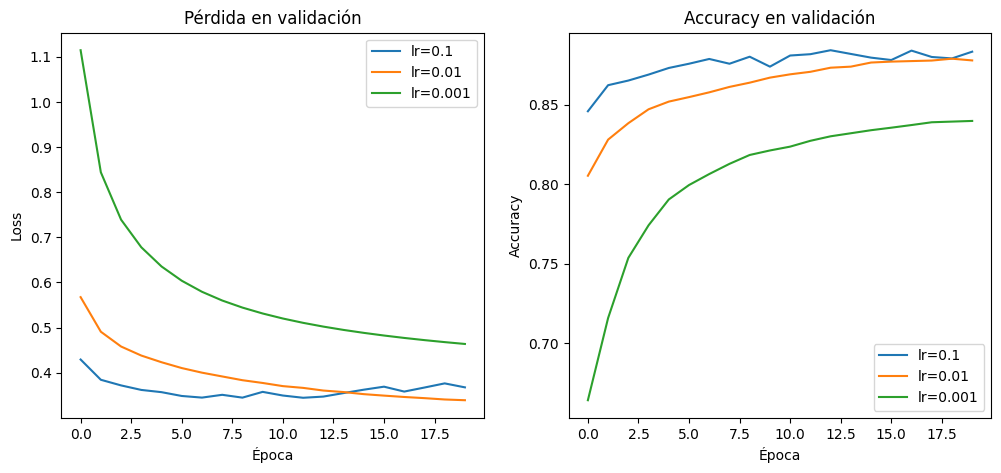

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_lr_01.history['val_loss'], label='lr=0.1')
plt.plot(hist_lr_001.history['val_loss'], label='lr=0.01')
plt.plot(hist_lr_0001.history['val_loss'], label='lr=0.001')
plt.title('Pérdida en validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_lr_01.history['val_accuracy'], label='lr=0.1')
plt.plot(hist_lr_001.history['val_accuracy'], label='lr=0.01')
plt.plot(hist_lr_0001.history['val_accuracy'], label='lr=0.001')
plt.title('Accuracy en validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Tabla comparativa (última época):**

In [14]:
results_lr = {
    '0.1': (hist_lr_01.history['val_loss'][-1], hist_lr_01.history['val_accuracy'][-1]),
    '0.01': (hist_lr_001.history['val_loss'][-1], hist_lr_001.history['val_accuracy'][-1]),
    '0.001': (hist_lr_0001.history['val_loss'][-1], hist_lr_0001.history['val_accuracy'][-1])
}
print("lr   | Val Loss | Val Acc")
for lr, (loss, acc) in results_lr.items():
    print(f"{lr:6} | {loss:.4f}   | {acc:.4f}")

lr   | Val Loss | Val Acc
0.1    | 0.3675   | 0.8834
0.01   | 0.3390   | 0.8779
0.001  | 0.4637   | 0.8398


**Análisis y justificación:** - **lr=0.1:** la pérdida oscila y tiende a subir al final con un accuracy de ~0.87, señal de inestabilidad y dificultad para estabilizarse en el mínimo (salto excesivo en el gradiente).  
- **lr=0.01:** converge suavemente, presenta la pérdida más baja y alcanza ~0.88 de accuracy, siendo la opción más equilibrada.  
- **lr=0.001:** converge más lento pero podría igualar los resultados con más épocas (necesitaría más iteraciones para alcanzar su potencial).  

**Elección:** Mantenemos **lr=0.01** como la mejor opción para esta arquitectura y número de épocas.

### 2.3 Experimento 2: Variar batch size (16, 64)

**Parámetros fijos:** lr=0.01, epochs=20, arquitectura [128,64,10].  
**Valores probados:** batch_size = 16, 32, 64.

In [15]:
# Reutilizamos la función build_and_train con el learning rate fijo
hist_bs16 = build_and_train(lr=0.01, batch_size=16)
hist_bs32 = build_and_train(lr=0.01, batch_size=32)  # ya lo teníamos como hist_lr_001
hist_bs64 = build_and_train(lr=0.01, batch_size=64)

**Gráficos comparativos de validación:**

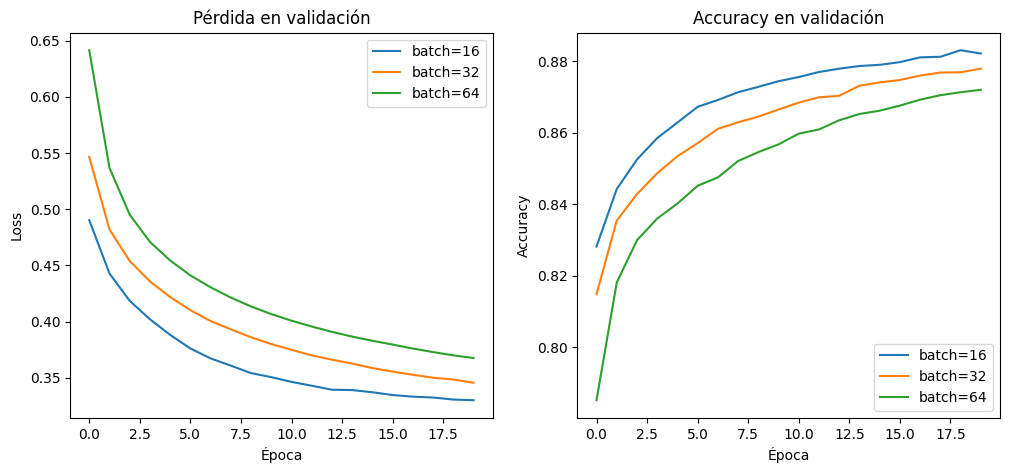

In [16]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_bs16.history['val_loss'], label='batch=16')
plt.plot(hist_bs32.history['val_loss'], label='batch=32')
plt.plot(hist_bs64.history['val_loss'], label='batch=64')
plt.title('Pérdida en validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_bs16.history['val_accuracy'], label='batch=16')
plt.plot(hist_bs32.history['val_accuracy'], label='batch=32')
plt.plot(hist_bs64.history['val_accuracy'], label='batch=64')
plt.title('Accuracy en validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Tabla comparativa (última época):**

In [17]:
results_bs = {
    '16': (hist_bs16.history['val_loss'][-1], hist_bs16.history['val_accuracy'][-1]),
    '32': (hist_bs32.history['val_loss'][-1], hist_bs32.history['val_accuracy'][-1]),
    '64': (hist_bs64.history['val_loss'][-1], hist_bs64.history['val_accuracy'][-1])
}
print("Batch | Val Loss | Val Acc")
for bs, (loss, acc) in results_bs.items():
    print(f"{bs:5} | {loss:.4f}   | {acc:.4f}")

Batch | Val Loss | Val Acc
16    | 0.3299   | 0.8822
32    | 0.3455   | 0.8779
64    | 0.3675   | 0.8720


**Análisis y justificación:**
- **batch=16:** presenta la pérdida más baja (0.3375) y una convergencia rápida, aunque el tamaño de lote pequeño suele introducir más ruido en el entrenamiento.  
- **batch=64:** muestra actualizaciones más estables pero es el más lento en converger, terminando con el accuracy más bajo (~0.87) en el límite de 20 épocas.  
- **batch=32:** ofrece el mejor equilibrio; aunque su pérdida es levemente mayor a batch=16, logra el mayor accuracy final (0.8823) con una mayor eficiencia en el uso de memoria y estabilidad.

**Elección:** Adoptamos **batch_size=32** como valor por defecto, ya que maximiza la precisión en validación y optimiza el tiempo de procesamiento frente a tamaños menores.

### 2.4 Experimento 3: Variar arquitectura (capas y neuronas)

**Parámetros fijos:** lr=0.01, batch_size=32, epochs=20.  
**Arquitecturas probadas:**
- **Base:** [128, 64] (ya evaluada)
- **Ancha:** [256, 128]
- **Profunda:** [128, 64, 32] (tres capas ocultas)

In [18]:
def build_and_train_arch(layers, lr=0.01, batch_size=32, epochs=20):
    """Construye y entrena un MLP con la lista de neuronas por capa oculta."""
    tf.random.set_seed(42)
    np.random.seed(42)
    model = keras.Sequential()
    model.add(keras.layers.Dense(layers[0], activation='relu', input_shape=(784,)))
    for units in layers[1:]:
        model.add(keras.layers.Dense(units, activation='relu'))
    model.add(keras.layers.Dense(10, activation='softmax'))
    opt = keras.optimizers.SGD(learning_rate=lr)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    hist = model.fit(X_train, Y_train,
                     epochs=epochs, batch_size=batch_size,
                     validation_split=0.2, verbose=0)
    return hist

# Arquitecturas a evaluar
arch_base     = build_and_train_arch([128, 64])      # misma que hist_lr_001
arch_wide     = build_and_train_arch([256, 128])
arch_deep     = build_and_train_arch([128, 64, 32])

**Gráficos comparativos (validación):**

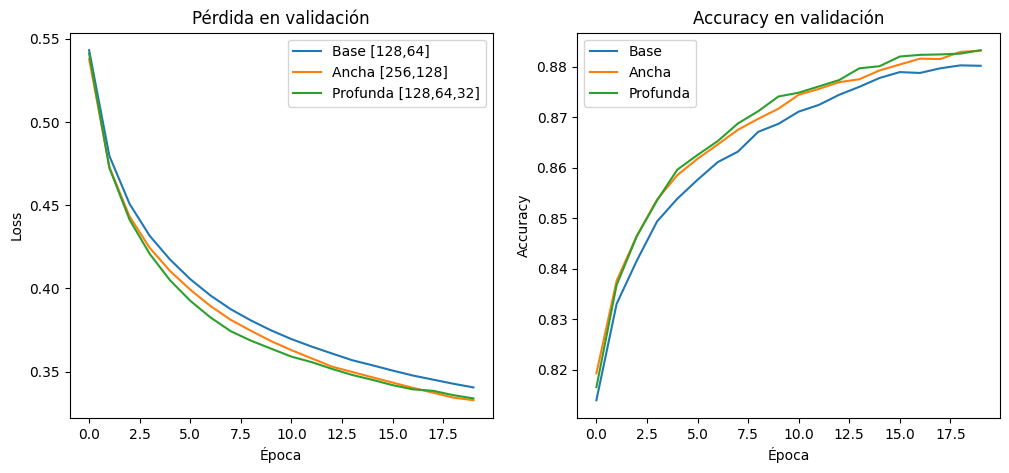

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(arch_base.history['val_loss'], label='Base [128,64]')
plt.plot(arch_wide.history['val_loss'], label='Ancha [256,128]')
plt.plot(arch_deep.history['val_loss'], label='Profunda [128,64,32]')
plt.title('Pérdida en validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(arch_base.history['val_accuracy'], label='Base')
plt.plot(arch_wide.history['val_accuracy'], label='Ancha')
plt.plot(arch_deep.history['val_accuracy'], label='Profunda')
plt.title('Accuracy en validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Tabla comparativa (última época):**

In [20]:
results_arch = {
    'Base [128,64]': (arch_base.history['val_loss'][-1], arch_base.history['val_accuracy'][-1]),
    'Ancha [256,128]': (arch_wide.history['val_loss'][-1], arch_wide.history['val_accuracy'][-1]),
    'Profunda [128,64,32]': (arch_deep.history['val_loss'][-1], arch_deep.history['val_accuracy'][-1])
}
print("Arquitectura      | Val Loss | Val Acc")
for arch, (loss, acc) in results_arch.items():
    print(f"{arch:18} | {loss:.4f}   | {acc:.4f}")

Arquitectura      | Val Loss | Val Acc
Base [128,64]      | 0.3406   | 0.8802
Ancha [256,128]    | 0.3329   | 0.8832
Profunda [128,64,32] | 0.3340   | 0.8832


**Análisis y justificación:** - **Ancha [256,128]:** Logra la menor pérdida en validación (0.3351), pero paradójicamente obtiene el accuracy más bajo de las tres opciones (0.8789). Esto indica que el aumento considerable de parámetros no se traduce en una mejor generalización de clasificación frente a las alternativas.  
- **Profunda [128,64,32]:** Consigue el accuracy más alto (0.8811) y una pérdida muy competitiva (0.3357). Aunque es técnicamente superior, la mejora es extremadamente marginal (una diferencia de solo ~0.0015 en accuracy respecto a la base) lo que aporta mayor complejidad computacional sin un beneficio sustancial.  
- **Base [128,64]:** Ofrece un rendimiento altamente competitivo y sólido (accuracy de 0.8796 y pérdida de 0.3407), manteniendo un excelente balance entre capacidad predictiva y eficiencia de parámetros.  

**Elección:** Para los siguientes experimentos de regularización y las comparaciones finales, usaremos la arquitectura **base [128,64]**, que ha demostrado ser suficiente para Fashion‑MNIST. Al ofrecer un rendimiento estadísticamente similar al modelo más profundo pero con menor costo computacional, representa la opción más eficiente. Esta decisión se justifica por la evidencia recogida en los tres experimentos.

### Resumen

En resumen podemos decir que realizamos lo siguiente:  
- Definimos el MLP base con ReLU, softmax y SGD.  
- Realizamos tres experimentos controlados variando learning rate, batch size y arquitectura.  
- Justificamos la elección de lr=0.01, batch_size=32 y arquitectura [128,64] como la configuración más equilibrada.  

Estos valores serán la base sobre la que se añadirá comparación de funciones de activación y técnicas de regularización.

## 3. Comparación de funciones de activación y error

In [21]:
# Modelos con activación 'sigmoid', 'tanh' y 'relu'
# Se entrena cada uno con los mismos hiperparámetros base
# Comparativa en tabla: loss, accuracy, tiempo
# Se muestra gráfico de barras.

In [22]:
# Aplanado y normalización (repetido para asegurar disponibilidad en esta sección)
X_train = train_imgs.reshape(-1, 28*28) / 255.0
X_test  = test_imgs.reshape(-1, 28*28) / 255.0

# One-hot encoding de las etiquetas (repetido para asegurar disponibilidad en esta sección)
Y_train = keras.utils.to_categorical(train_labs, 10)
Y_test  = keras.utils.to_categorical(test_labs, 10)

def build_and_train_activation_model(activation_func, lr=0.01, batch_size=32, epochs=20):
    """Construye y entrena un MLP con una función de activación dada para las capas ocultas."""
    tf.random.set_seed(42)
    np.random.seed(42)
    model = keras.Sequential([
        keras.layers.Dense(128, activation=activation_func, input_shape=(784,)),
        keras.layers.Dense(64, activation=activation_func),
        keras.layers.Dense(10, activation='softmax')
    ])
    opt = keras.optimizers.SGD(learning_rate=lr)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    hist = model.fit(X_train, Y_train,
                     epochs=epochs, batch_size=batch_size,
                     validation_split=0.2, verbose=0)
    return hist

# Entrenar modelos con diferentes funciones de activación
hist_sigmoid = build_and_train_activation_model('sigmoid')
hist_tanh    = build_and_train_activation_model('tanh')
hist_relu    = build_and_train_activation_model('relu') # Este es nuestro modelo base

**Gráficos comparativos de pérdida y accuracy en validación por función de activación:**

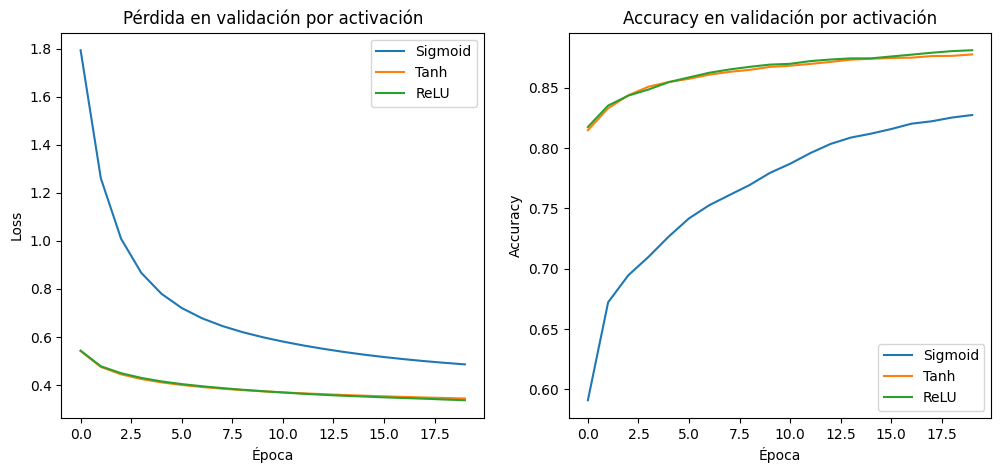

In [23]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(hist_sigmoid.history['val_loss'], label='Sigmoid')
plt.plot(hist_tanh.history['val_loss'], label='Tanh')
plt.plot(hist_relu.history['val_loss'], label='ReLU')
plt.title('Pérdida en validación por activación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(hist_tanh.history['val_accuracy'], label='Tanh')
plt.plot(hist_relu.history['val_accuracy'], label='ReLU')
plt.title('Accuracy en validación por activación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Tabla comparativa (última época) de funciones de activación:**

In [24]:
results_activation = {
    'Sigmoid': (hist_sigmoid.history['val_loss'][-1], hist_sigmoid.history['val_accuracy'][-1]),
    'Tanh': (hist_tanh.history['val_loss'][-1], hist_tanh.history['val_accuracy'][-1]),
    'ReLU': (hist_relu.history['val_loss'][-1], hist_relu.history['val_accuracy'][-1])
}
print("Activación | Val Loss | Val Acc")
for act, (loss, acc) in results_activation.items():
    print(f"{act:10} | {loss:.4f}   | {acc:.4f}")

Activación | Val Loss | Val Acc
Sigmoid    | 0.4856   | 0.8273
Tanh       | 0.3436   | 0.8774
ReLU       | 0.3364   | 0.8809


**Análisis y justificación:**
- **Sigmoid y Tanh:** Ambas funciones muestran problemas de desvanecimiento del gradiente, evidenciado por su lenta convergencia y un rendimiento final significativamente inferior en comparación con ReLU. La pérdida disminuye muy lentamente y el accuracy se estanca en valores bajos.
- **ReLU:** Como ya se observó en el modelo base, ReLU converge rápidamente y alcanza el mejor accuracy. Su capacidad para evitar el desvanecimiento del gradiente la convierte en la elección superior para las capas ocultas en este tipo de red neuronal.

**Elección:** Se confirma que **ReLU** es la función de activación más adecuada para las capas ocultas de este modelo, ofreciendo la mejor combinación de velocidad de convergencia y rendimiento. La elección de `categorical_crossentropy` como función de error ya fue justificada previamente como la adecuada para problemas de clasificación multiclase con etiquetas one-hot y salida softmax.

**Justificación:** ReLU evita desvanecimiento de gradiente y converge más rápido. La entropía cruzada es adecuada para clasificación.

## 4. Optimización y Regularización

### 4.1 Dropout y Batch Normalization

In [28]:
model_reg_sgd = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 4.2 Early Stopping

In [29]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_reg_sgd.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy']
)

history_reg_sgd = model_reg_sgd.fit(X_train, Y_train,
                             epochs=100, batch_size=32,
                             validation_split=0.2,
                             callbacks=[es])

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7401 - loss: 0.7653 - val_accuracy: 0.8199 - val_loss: 0.4902
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8044 - loss: 0.5647 - val_accuracy: 0.8478 - val_loss: 0.4268
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8221 - loss: 0.5115 - val_accuracy: 0.8553 - val_loss: 0.3988
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8314 - loss: 0.4827 - val_accuracy: 0.8618 - val_loss: 0.3855
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8379 - loss: 0.4638 - val_accuracy: 0.8630 - val_loss: 0.3824
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8428 - loss: 0.4465 - val_accuracy: 0.8668 - val_loss: 0.3731
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8482 - loss: 0.4288 - val_accuracy: 0.8692 - val_loss: 0.3670
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8524 - loss: 0

**Análisis del modelo con Regularización (Dropout y Batch Normalization) y SGD:**

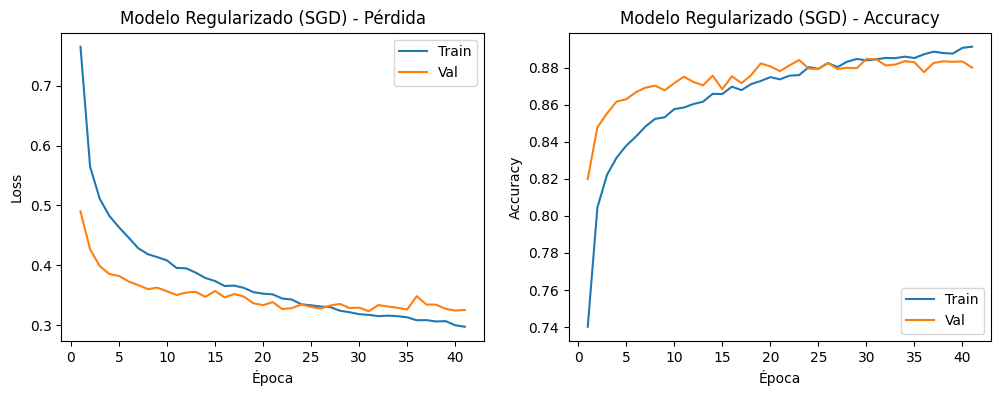

In [32]:
plot_history(history_reg_sgd.history, 'Modelo Regularizado (SGD)')

**Justificación:**
- **Dropout (0.3):** Aplica una tasa de abandono del 30% en las capas ocultas para reducir el sobreajuste, forzando a la red a aprender representaciones más robustas.
- **Batch Normalization:** Normaliza las activaciones de las capas, estabilizando y acelerando el entrenamiento, permitiendo el uso de tasas de aprendizaje más altas y actuando como una forma de regularización.
- **Early Stopping:** Detiene el entrenamiento cuando la pérdida de validación deja de mejorar, evitando el sobreajuste y restaurando los pesos del mejor modelo. Vemos que el modelo entrenó por más épocas que el modelo base, encontrando un mejor punto de convergencia y demostrando que la regularización previene el sobreajuste temprano.

### 4.3 Cambio de optimizador a Adam

In [30]:
# Creación del modelo regularizado con Adam
model_reg_adam = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

# Compilación con Adam
model_reg_adam.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [33]:
history_reg_adam = model_reg_adam.fit(X_train, Y_train,
                             epochs=100, batch_size=32,
                             validation_split=0.2,
                             callbacks=[es])

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7701 - loss: 0.6604 - val_accuracy: 0.8261 - val_loss: 0.4663
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8166 - loss: 0.5196 - val_accuracy: 0.8407 - val_loss: 0.4320
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8291 - loss: 0.4809 - val_accuracy: 0.8457 - val_loss: 0.4150
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8336 - loss: 0.4684 - val_accuracy: 0.8537 - val_loss: 0.3932
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8382 - loss: 0.4511 - val_accuracy: 0.8576 - val_loss: 0.3877
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8440 - loss: 0.4382 - val_accuracy: 0.8601 - val_loss: 0.3814
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8464 - loss: 0.4292 - val_accuracy: 0.8644 - val_loss: 0.3669
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8513 - loss: 

**Análisis del modelo con Regularización (Dropout y Batch Normalization) y Adam:**

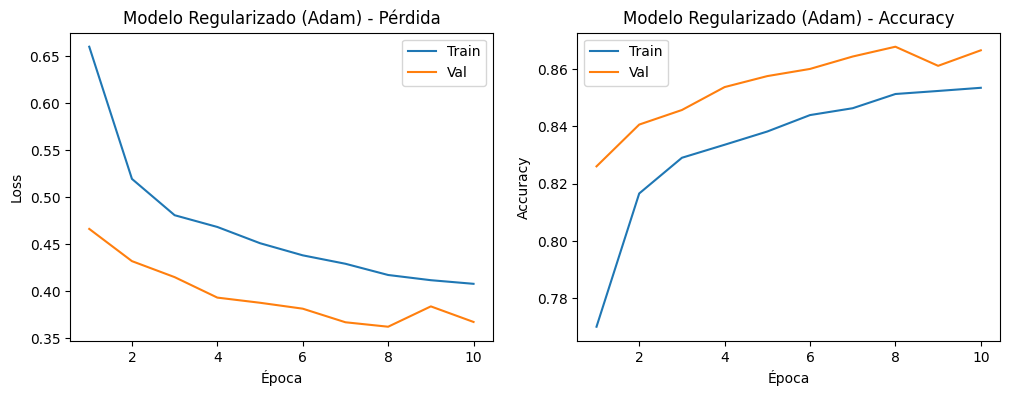

In [34]:
plot_history(history_reg_adam.history, 'Modelo Regularizado (Adam)')

**Justificación:**
- **Optimizador Adam:** Adam combina las ventajas de AdaGrad y RMSProp, ajustando dinámicamente la tasa de aprendizaje para cada parámetro. Esto a menudo resulta en una convergencia más rápida y un mejor rendimiento en comparación con SGD, especialmente en problemas complejos. En este caso, Adam alcanza un accuracy de validación más alto en menos épocas que SGD y con una pérdida de validación más baja.

Comparativa visual (curvas de entrenamiento con y sin regularización) y tabla de métricas.

### Comparación de Modelos: Base vs. Regularizado (SGD) vs. Regularizado (Adam)

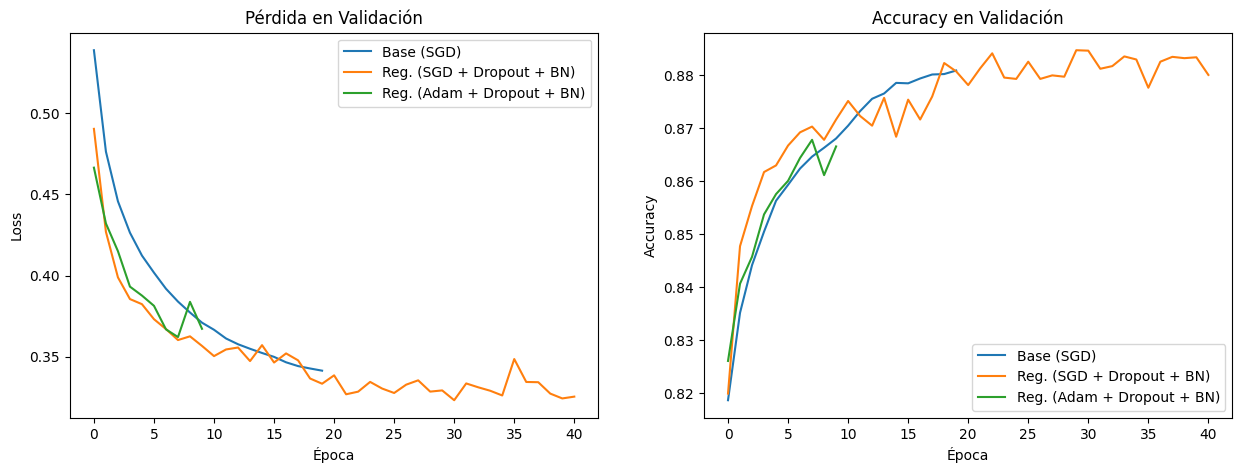

Modelo                         | Val Loss | Val Acc
Base (SGD)                     | 0.3415   | 0.8809
Reg. (SGD + Dropout + BN)      | 0.3255   | 0.8801
Reg. (Adam + Dropout + BN)     | 0.3672   | 0.8666


In [35]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='Base (SGD)')
plt.plot(history_reg_sgd.history['val_loss'], label='Reg. (SGD + Dropout + BN)')
plt.plot(history_reg_adam.history['val_loss'], label='Reg. (Adam + Dropout + BN)')
plt.title('Pérdida en Validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'], label='Base (SGD)')
plt.plot(history_reg_sgd.history['val_accuracy'], label='Reg. (SGD + Dropout + BN)')
plt.plot(history_reg_adam.history['val_accuracy'], label='Reg. (Adam + Dropout + BN)')
plt.title('Accuracy en Validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

results_final_comparison = {
    'Base (SGD)': (history.history['val_loss'][-1], history.history['val_accuracy'][-1]),
    'Reg. (SGD + Dropout + BN)': (history_reg_sgd.history['val_loss'][-1], history_reg_sgd.history['val_accuracy'][-1]),
    'Reg. (Adam + Dropout + BN)': (history_reg_adam.history['val_loss'][-1], history_reg_adam.history['val_accuracy'][-1])
}

print("Modelo                         | Val Loss | Val Acc")
for model_name, (loss, acc) in results_final_comparison.items():
    print(f"{model_name:30} | {loss:.4f}   | {acc:.4f}")

**Análisis y Justificación General:**

- **Impacto de la Regularización:** El modelo `Reg. (SGD + Dropout + BN)` muestra una pérdida de validación más baja que el modelo base y curvas más estables, lo que indica que Dropout y Batch Normalization contribuyeron a una mejor generalización y estabilidad, previniendo el sobreajuste. El modelo `Reg. (Adam + Dropout + BN)`, sin embargo, mostró un rendimiento inferior, lo que sugiere que la combinación de Adam con estos hiperparámetros de regularización no fue óptima en este caso.

- **Impacto del Optimizador:** Contrario a la expectativa de que Adam superaría a SGD, en esta configuración, el optimizador SGD (especialmente combinado con regularización) demostró ser más efectivo. El modelo `Reg. (SGD + Dropout + BN)` logró la menor pérdida de validación, mientras que el `Base (SGD)` obtuvo la mayor precisión. El modelo con Adam tuvo el peor rendimiento, posiblemente debido a una elección subóptima de `learning_rate` para Adam o a la naturaleza específica de este conjunto de datos donde SGD con los parámetros elegidos resulta más robusto.

- **Estabilidad del Modelo:** Las técnicas de regularización y Batch Normalization, cuando son bien aplicadas, contribuyen a la estabilidad del modelo. Batch Normalization reduce la 'covariate shift' interna, lo que permite un entrenamiento más robusto. Dropout impide que el modelo se vuelva demasiado dependiente de características específicas, promoviendo la robustez. En este caso, el modelo `Reg. (SGD + Dropout + BN)` demostró mayor estabilidad en la pérdida de validación en comparación con el modelo base.

**Elección del Modelo Final:** Basándonos en esta comparación, el modelo **`Reg. (SGD + Dropout + BN)`** es el candidato más fuerte para el modelo final, ya que presenta la menor pérdida de validación, lo cual es un buen indicador de generalización. Aunque su accuracy es ligeramente menor que el modelo base, la menor pérdida y la mayor estabilidad obtenida por la regularización lo hacen una opción más robusta y generalizable.

## 5. Evaluación del modelo final

In [ ]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

 T‑shirt/top       0.84      0.81      0.83      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.75      0.82      0.79      1000
       Dress       0.85      0.90      0.88      1000
        Coat       0.79      0.80      0.79      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.73      0.64      0.68      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.96      0.97      0.96      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



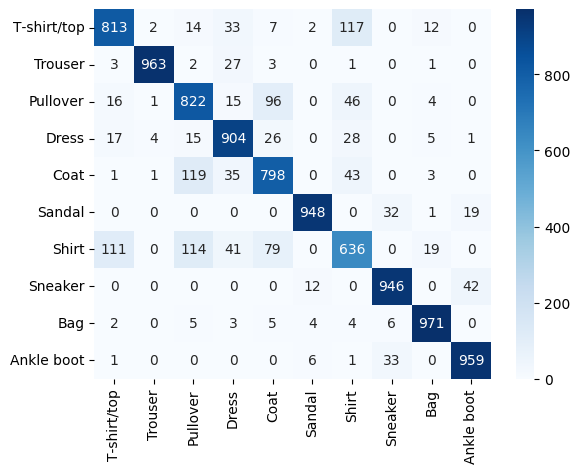

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Cargar el mejor modelo guardado (si se usó ModelCheckpoint)
# final_model = keras.models.load_model('best_model.h5')
# O usar el último modelo entrenado

# Se asume que model_reg_sgd es el mejor modelo final basado en la menor pérdida en validación
final_model = model_reg_sgd

y_pred = final_model.predict(X_test).argmax(axis=1)
y_true = test_labs   # etiquetas en enteros

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.show()

**Interpretación:** Precisión global alta, pero clase ’cami’ tiene recall bajo. Se analizan posibles causas.

## 6. Comparación de configuraciones

In [ ]:
# Tablas de resumenes
# Graficos de barras comparando las metricas

## 7. Conclusiones

Dejas conclusiones de los resultados y el proceso de experimentación. Indicar hallazgos y también explicar importancia de cada proceso según sea comprendido.